<a href="https://colab.research.google.com/github/samiraghafarigousheh-sys/PyBuildingEnergy_AIBteam_AU/blob/main/Copy_of_calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pybuildingenergy requests pandas matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 50.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.4/98.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.0/633.0 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 26.3 MB/s eta 0:00:00
   ━━━━━

In [ ]:
import os, sys, copy, re, glob, shutil, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WEATHER_SOURCE ="pvgis"
FLOOR_AREA     = 5.0 * 4.0   # m²


In [ ]:
def build_bui():
    """Returns a fresh copy of the Apt 305 building dictionary (no shared state)."""

    # --- Construction U-values & thermal capacity — Australian BCA 2006 minimum-spec ---
    U_EXT_WALL  = 1.00   # brick veneer / precast w/ R1.0 insulation
    U_INT_WALL  = 2.50   # concrete block + plasterboard, no insulation
    U_INT_SLAB  = 1.80   # 200 mm concrete intermediate floor
    U_WINDOW    = 5.40   # aluminium-frame single glazing
    G_WINDOW    = 0.65   # SHGC of clear single glazing

    ABS_EXT_WALL = 0.75  # dark red brick
    ABS_INT      = 0.0

    C_EXT_WALL = 0          # thermal mass zeroed for engine-method-only comparison
    C_INT_WALL = 0          # thermal mass zeroed for engine-method-only comparison
    C_INT_SLAB = 0          # thermal mass zeroed for engine-method-only comparison
    C_WINDOW   = 0

    # --- Geometry ---
    LEN_NS  = 5.0   # N-S length, m (west facade width, along Barry St)
    LEN_EW  = 4.0   # E-W depth, m
    HEIGHT  = 2.7   # ceiling height, m

    FLOOR_AREA = LEN_NS * LEN_EW
    VOLUME     = FLOOR_AREA * HEIGHT

    A_WEST_GROSS  = LEN_NS * HEIGHT
    A_EAST_GROSS  = LEN_NS * HEIGHT
    A_NORTH_GROSS = LEN_EW * HEIGHT
    A_SOUTH_GROSS = LEN_EW * HEIGHT

    WIN_WIDTH_FIXED,    WIN_HEIGHT_FIXED    = 0.9, 0.9
    WIN_WIDTH_OPERABLE, WIN_HEIGHT_OPERABLE = 0.9, 0.9
    A_WINDOW_FIXED    = WIN_WIDTH_FIXED * WIN_HEIGHT_FIXED
    A_WINDOW_OPERABLE = WIN_WIDTH_OPERABLE * WIN_HEIGHT_OPERABLE
    A_WINDOW_TOTAL    = A_WINDOW_FIXED + A_WINDOW_OPERABLE
    A_WEST_OPAQUE     = A_WEST_GROSS - A_WINDOW_TOTAL

    bui = {
        "building": {
            "name": "Apt_305_50_Barry_St_Carlton",
            "azimuth_relative_to_true_north": 0,
            "latitude":  -37.800,
            "longitude": 144.968,
            "exposed_perimeter": 0,
            "height": HEIGHT,
            "wall_thickness": 0.20,
            "n_floors": 1,
            "building_type_class": "Residential_apartment",
            "adj_zones_present": True,
            "number_adj_zone": 5,
            "net_floor_area": FLOOR_AREA,
            "construction_class": "class_iii",
            "construction_year": "2006-today",
            "country": "Australia",
        },
        "adjacent_zones": [
            {
                "name": "apt_above",
                "orientation_zone": {"azimuth": 270.0},
                "area_facade_elements": np.array([A_WEST_GROSS, A_NORTH_GROSS, A_EAST_GROSS, A_SOUTH_GROSS, FLOOR_AREA, FLOOR_AREA]),
                "typology_elements": ["OP", "OP", "OP", "OP", "OP", "OP"],
                "transmittance_U_elements": np.array([U_EXT_WALL, U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_SLAB, U_INT_SLAB]),
                "orientation_elements": np.array(["WV", "NV", "EV", "SV", "HOR", "HOR"]),
                "volume": VOLUME,
                "building_type_class": "Residential_apartment",
                "a_use": FLOOR_AREA,
            },
            {
                "name": "apt_below",
                "orientation_zone": {"azimuth": 270.0},
                "area_facade_elements": np.array([A_WEST_GROSS, A_NORTH_GROSS, A_EAST_GROSS, A_SOUTH_GROSS, FLOOR_AREA, FLOOR_AREA]),
                "typology_elements": ["OP", "OP", "OP", "OP", "OP", "OP"],
                "transmittance_U_elements": np.array([U_EXT_WALL, U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_SLAB, U_INT_SLAB]),
                "orientation_elements": np.array(["WV", "NV", "EV", "SV", "HOR", "HOR"]),
                "volume": VOLUME,
                "building_type_class": "Residential_apartment",
                "a_use": FLOOR_AREA,
            },
            {
                "name": "apt_north",
                "orientation_zone": {"azimuth": 0.0},
                "area_facade_elements": np.array([A_WEST_GROSS, A_NORTH_GROSS, A_EAST_GROSS, A_SOUTH_GROSS, FLOOR_AREA, FLOOR_AREA]),
                "typology_elements": ["OP", "OP", "OP", "OP", "OP", "OP"],
                "transmittance_U_elements": np.array([U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_SLAB, U_INT_SLAB]),
                "orientation_elements": np.array(["WV", "NV", "EV", "SV", "HOR", "HOR"]),
                "volume": VOLUME,
                "building_type_class": "Residential_apartment",
                "a_use": FLOOR_AREA,
            },
            {
                "name": "apt_south",
                "orientation_zone": {"azimuth": 180.0},
                "area_facade_elements": np.array([A_WEST_GROSS, A_NORTH_GROSS, A_EAST_GROSS, A_SOUTH_GROSS, FLOOR_AREA, FLOOR_AREA]),
                "typology_elements": ["OP", "OP", "OP", "OP", "OP", "OP"],
                "transmittance_U_elements": np.array([U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_SLAB, U_INT_SLAB]),
                "orientation_elements": np.array(["WV", "NV", "EV", "SV", "HOR", "HOR"]),
                "volume": VOLUME,
                "building_type_class": "Residential_apartment",
                "a_use": FLOOR_AREA,
            },
            {
                "name": "corridor",
                "orientation_zone": {"azimuth": 90.0},
                "area_facade_elements": np.array([81.0, 5.4, 81.0, 5.4, 60.0, 60.0]),
                "typology_elements": ["OP", "OP", "OP", "OP", "OP", "OP"],
                "transmittance_U_elements": np.array([U_INT_WALL] * 6),
                "orientation_elements": np.array(["WV", "NV", "EV", "SV", "HOR", "HOR"]),
                "volume": 162.0,
                "building_type_class": "Residential_apartment",
                "a_use": 60.0,
            },
        ],
        "building_surface": [
            {
                "name": "West exterior wall (opaque)", "type": "opaque", "area": A_WEST_OPAQUE,
                "sky_view_factor": 0.5, "u_value": U_EXT_WALL, "solar_absorptance": ABS_EXT_WALL,
                "thermal_capacity": C_EXT_WALL, "orientation": {"azimuth": 270.0, "tilt": 90.0},
                "name_adj_zone": None, "height": HEIGHT, "length": LEN_NS,
            },
            {
                "name": "North wall to Apt 306", "type": "opaque", "area": A_NORTH_GROSS,
                "sky_view_factor": 0.0, "u_value": U_INT_WALL, "solar_absorptance": ABS_INT,
                "thermal_capacity": C_INT_WALL, "orientation": {"azimuth": 0.0, "tilt": 90.0},
                "name_adj_zone": "apt_north", "height": HEIGHT, "length": LEN_EW,
            },
            {
                "name": "South wall to Apt 304", "type": "opaque", "area": A_SOUTH_GROSS,
                "sky_view_factor": 0.0, "u_value": U_INT_WALL, "solar_absorptance": ABS_INT,
                "thermal_capacity": C_INT_WALL, "orientation": {"azimuth": 180.0, "tilt": 90.0},
                "name_adj_zone": "apt_south", "height": HEIGHT, "length": LEN_EW,
            },
            {
                "name": "East wall to corridor", "type": "opaque", "area": A_EAST_GROSS,
                "sky_view_factor": 0.0, "u_value": U_INT_WALL, "solar_absorptance": ABS_INT,
                "thermal_capacity": C_INT_WALL, "orientation": {"azimuth": 90.0, "tilt": 90.0},
                "name_adj_zone": "corridor", "height": HEIGHT, "length": LEN_NS,
            },
            {
                "name": "Floor to Apt 205", "type": "opaque", "area": FLOOR_AREA,
                "sky_view_factor": 0.0, "u_value": U_INT_SLAB, "solar_absorptance": ABS_INT,
                "thermal_capacity": C_INT_SLAB, "orientation": {"azimuth": 0.0, "tilt": 0.0},
                "name_adj_zone": "apt_below", "height": LEN_NS, "length": LEN_EW,
            },
            {
                "name": "Ceiling to Apt 405", "type": "opaque", "area": FLOOR_AREA,
                "sky_view_factor": 0.0, "u_value": U_INT_SLAB, "solar_absorptance": ABS_INT,
                "thermal_capacity": C_INT_SLAB, "orientation": {"azimuth": 0.0, "tilt": 0.0},
                "name_adj_zone": "apt_above", "height": LEN_NS, "length": LEN_EW,
            },
            {
                "name": "West window — fixed", "type": "transparent", "area": A_WINDOW_FIXED,
                "sky_view_factor": 0.5, "u_value": U_WINDOW, "solar_absorptance": 0.5,
                "thermal_capacity": C_WINDOW, "orientation": {"azimuth": 270.0, "tilt": 90.0},
                "name_adj_zone": None, "height": WIN_HEIGHT_FIXED, "g_value": G_WINDOW,
                "width": WIN_WIDTH_FIXED, "parapet": 1.0, "shading": True,
                "shading_type": "horizontal_overhang", "width_or_distance_of_shading_elements": 0.05,
                "overhang_proprieties": {"width_of_horizontal_overhangs": 0.25},
            },
            {
                "name": "West window — operable", "type": "transparent", "area": A_WINDOW_OPERABLE,
                "sky_view_factor": 0.5, "u_value": U_WINDOW, "solar_absorptance": 0.5,
                "thermal_capacity": C_WINDOW, "orientation": {"azimuth": 270.0, "tilt": 90.0},
                "name_adj_zone": None, "height": WIN_HEIGHT_OPERABLE, "g_value": G_WINDOW,
                "width": WIN_WIDTH_OPERABLE, "parapet": 1.0, "shading": True,
                "shading_type": "horizontal_overhang", "width_or_distance_of_shading_elements": 0.05,
                "overhang_proprieties": {"width_of_horizontal_overhangs": 0.25},
            },
        ],
        "units": {
            "area": "m\u00b2", "u_value": "W/m\u00b2K", "thermal_capacity": "J/m\u00b2K",
            "azimuth": "degrees (0=N, 90=E, 180=S, 270=W)", "tilt": "degrees (0=horizontal, 90=vertical)",
            "internal_gain": "W/m\u00b2", "HVAC_profile": "0: off, 1: on",
        },
        "building_parameters": {
            "temperature_setpoints": {
                # Fixed setpoints, as used in copy_of_pybuildingenergy_my_house.ipynb.
                # The modified-engine cell overrides these with NCC zone-derived setpoints.
                "heating_setpoint": 18.0,
                "heating_setback":  15.0,
                "cooling_setpoint": 26.0,
                "cooling_setback":  28.0,
                "units": "\u00b0C",
            },
            "system_capacities": {
                "heating_capacity": 10_000_000.0,
                "cooling_capacity": 10_000_000.0,
                "units": "W",
            },
            "ventilation": {
                "ventilation_type": "occupancy",
                "flow_rate_per_person": 2.0,
                "units": "l/(s m\u00b2)",
                "custom_heat_transfer_coefficient_ventilation": None,
            },
            "internal_gains": [
                {
                    "name": "occupants", "full_load": 8.0,  # 2 people × 80 W/person sensible = 8 W/m²
                    "weekday": [1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.4,0.5,0.5,0.5,0.4,0.5,0.5,0.5,0.5,0.5,1.0,1.0,1.0,1.0],
                    "weekend": [1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.8,0.7,0.7,0.7,0.7,0.5,0.5,0.7,0.8,1.0,1.0,1.0,1.0,1.0,1.0],
                },
                {
                    "name": "appliances", "full_load": 5.0,   # reduced to 5 W/m²
                    "weekday": [0.1,0.1,0.1,0.1,0.1,0.1,0.2,0.3,0.2,0.2,0.2,0.2,0.3,0.2,0.2,0.2,0.2,0.3,0.3,0.4,1.0,0.6,0.4,0.2],
                    "weekend": [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.2,0.3,0.4,0.3,0.3,0.4,0.3,0.3,0.3,0.3,0.4,0.4,0.5,1.0,0.6,0.4,0.2],
                },
                {
                    "name": "lighting", "full_load": 3.0,
                    "weekday": [0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.3,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.5,0.8,0.8,0.8,0.7,0.4,0.1],
                    "weekend": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.3,0.3,0.2,0.2,0.2,0.2,0.2,0.2,0.3,0.5,0.8,0.8,0.8,0.7,0.4,0.1],
                },
            ],
            "construction": {
                "wall_thickness": 0.20,
                "thermal_bridges": 1.5,
                "units": "m (thickness), W/mK (thermal bridges)",
            },
            "climate_parameters": {"coldest_month": 7, "units": "1-12 (January-December)"},
            "heating_profile": {
                "weekday": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0],
                "weekend": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0],
            },
            "cooling_profile": {
                "weekday": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0],
                "weekend": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0],
            },
            "ventilation_profile": {
                "weekday": [1.0] * 24,
                "weekend": [1.0] * 24,
            },
        },
    }
    return bui

FLOOR_AREA = build_bui()["building"]["net_floor_area"]
print(f"Floor area: {FLOOR_AREA} m2")


Floor area: 20.0 m2


In [ ]:
# ── Original pyBuildingEnergy (PyPI) ─────────────────────────────────────────
from pybuildingenergy.source.check_input import sanitize_and_validate_BUI as orig_sanitize
from pybuildingenergy.source.utils import ISO52016 as OrigISO52016
print("Original engine:", OrigISO52016.__module__)

Original engine: pybuildingenergy.source.utils


In [ ]:
# ── Modified AIB fork ─────────────────────────────────────────────────────────
FORK_DIR = "/content/pybuildingenergy_AIB_fork"
if not os.path.exists(FORK_DIR):
    subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/Sarthak790/pybuildinenergy_AIB.git", FORK_DIR],
        check=True, capture_output=True)
    print("Fork cloned.")

# Temporarily redirect imports to the fork
for mod_name in list(sys.modules):
    if mod_name == "pybuildingenergy" or mod_name.startswith("pybuildingenergy."):
        del sys.modules[mod_name]

FORK_SRC   = f"{FORK_DIR}/pyBuildingEnergy/src"
FORK_TESTS = f"{FORK_DIR}/pyBuildingEnergy/tests"
for _p in (FORK_SRC, FORK_TESTS):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from pybuildingenergy.source.check_input import sanitize_and_validate_BUI as mod_sanitize
from pybuildingenergy.source.utils import ISO52016 as ModISO52016
from climate_setpoints import get_ncc_setpoints, apply_setpoints_to_building

# Get NCC setpoints for Melbourne
_bui_tmp = build_bui()
ncc_setpoints = get_ncc_setpoints(
    lat=_bui_tmp["building"]["latitude"],
    lon=_bui_tmp["building"]["longitude"])

print("Modified engine:", ModISO52016.__module__)
print(f"NCC setpoints — heat: {ncc_setpoints['heating_setpoint']} °C  "
      f"cool: {ncc_setpoints['cooling_setpoint_living']} °C")

# Reload original engine (it was flushed above)
for mod_name in list(sys.modules):
    if mod_name == "pybuildingenergy" or mod_name.startswith("pybuildingenergy."):
        del sys.modules[mod_name]
# ⚠ CRITICAL: Remove fork paths from sys.path, otherwise Python still finds the
# fork first and we end up importing it again as "original", making both engines
# identical. This was the root cause of "Original and Modified produce same result".
sys.path = [p for p in sys.path if p not in (FORK_SRC, FORK_TESTS)]
import pybuildingenergy  # noqa: re-resolves to PyPI install
from pybuildingenergy.source.check_input import sanitize_and_validate_BUI as orig_sanitize
from pybuildingenergy.source.utils import ISO52016 as OrigISO52016
print("Original engine reloaded:", OrigISO52016.__module__)


In [ ]:
# ── EnergyPlus 24.1.0 — install via tar.gz (no interactive prompt) ───────────
import os, subprocess, sys, requests

EP_VERSION = "24.1.0"
EP_SHA     = "9d7789a3ac"
EP_DIR     = "/opt/energyplus"

if not os.path.exists(EP_DIR):
    tar_name = f"EnergyPlus-{EP_VERSION}-{EP_SHA}-Linux-Ubuntu22.04-x86_64.tar.gz"
    tar_url  = (
        f"https://github.com/NREL/EnergyPlus/releases/download/"
        f"v{EP_VERSION}/{tar_name}"
    )
    tar_path = f"/tmp/{tar_name}"

    print(f"Downloading EnergyPlus {EP_VERSION} (tar.gz) …")
    subprocess.run(["wget", "-q", "--show-progress", "-O", tar_path, tar_url], check=True)

    print("Extracting …")
    os.makedirs(EP_DIR, exist_ok=True)
    # --strip-components=1 removes the top-level folder inside the archive
    subprocess.run(
        ["tar", "-xzf", tar_path, "--strip-components=1", "-C", EP_DIR],
        check=True,
    )
    os.remove(tar_path)
    print(f"Installed → {EP_DIR}")
else:
    print(f"EnergyPlus already at {EP_DIR}")

# Confirm the binary exists before continuing
ep_bin = os.path.join(EP_DIR, "energyplus")
assert os.path.exists(ep_bin), f"energyplus binary not found in {EP_DIR}"
print(f"Binary OK: {ep_bin}")

if EP_DIR not in sys.path:
    sys.path.insert(0, EP_DIR)

# ── PVGIS TMY → EPW  (same weather source as the ISO 52016 simulations) ──────
EPW_PATH = "/content/Melbourne_PVGIS_TMY.epw"
if not os.path.exists(EPW_PATH):
    print("Downloading PVGIS TMY as EPW …")
    pvgis_url = (
        "https://re.jrc.ec.europa.eu/api/v5_2/tmy"
        "?lat=-37.800&lon=144.968&outputformat=epw"
    )
    r = requests.get(pvgis_url, timeout=120)
    r.raise_for_status()
    with open(EPW_PATH, "wb") as f:
        f.write(r.content)
    print(f"Saved EPW → {EPW_PATH}  ({len(r.content)//1024} kB)")
else:
    print(f"EPW already at {EPW_PATH}")

with open(EPW_PATH) as f:
    first = f.readline().strip()
print(f"EPW header: {first[:80]}")

Extracting …
Installed → /opt/energyplus
Binary OK: /opt/energyplus/energyplus
Saved EPW → /content/Melbourne_PVGIS_TMY.epw  (1824 kB)
EPW header: LOCATION,unknown,-,unknown,ECMWF/ERA,unknown,-37.800000,144.968000,10,52


In [ ]:
import glob, os, shutil, subprocess

# ── Re-define IDF builder here so this cell is self-contained ─────────────────
def _sf(name, wd, we):
    rows = ["Schedule:Compact,\n  {},\n  Fraction,\n  Through: 12/31,".format(name),
            "  For: Weekdays,"]
    for h, v in enumerate(wd, 1):
        rows.append("  Until: {:02d}:00,{},".format(h, v))
    rows.append("  For: AllOtherDays,")
    for h, v in enumerate(we, 1):
        rows.append("  Until: {:02d}:00,{}{}".format(h, v, "," if h < 24 else ";"))
    return "\n".join(rows)

def _st(name, wd, we):
    rows = ["Schedule:Compact,\n  {},\n  Temperature,\n  Through: 12/31,".format(name),
            "  For: Weekdays,"]
    for h, v in enumerate(wd, 1):
        rows.append("  Until: {:02d}:00,{},".format(h, v))
    rows.append("  For: AllOtherDays,")
    for h, v in enumerate(we, 1):
        rows.append("  Until: {:02d}:00,{}{}".format(h, v, "," if h < 24 else ";"))
    return "\n".join(rows)

def _make_idf(heating_sp=18.0, cooling_sp=26.0, heating_sb=15.0, cooling_sb=28.0):
    bui = build_bui()
    bp  = bui["building_parameters"]
    ig  = {g["name"]: g for g in bp["internal_gains"]}
    occ_wd = ig["occupants"]["weekday"];  occ_we = ig["occupants"]["weekend"]
    app_wd = ig["appliances"]["weekday"]; app_we = ig["appliances"]["weekend"]
    lit_wd = ig["lighting"]["weekday"];   lit_we = ig["lighting"]["weekend"]
    h_wd = bp["heating_profile"]["weekday"]; h_we = bp["heating_profile"]["weekend"]
    c_wd = bp["cooling_profile"]["weekday"]; c_we = bp["cooling_profile"]["weekend"]
    hsp_wd = [heating_sp if v > 0 else heating_sb for v in h_wd]
    hsp_we = [heating_sp if v > 0 else heating_sb for v in h_we]
    csp_wd = [cooling_sp if v > 0 else cooling_sb for v in c_wd]
    csp_we = [cooling_sp if v > 0 else cooling_sb for v in c_we]
    R_ext = round(max(0.001, 1/1.00 - 0.13 - 0.04), 4)
    R_int = round(max(0.001, 1/2.50 - 0.13 - 0.13), 4)
    R_slb = round(max(0.001, 1/1.80 - 0.13 - 0.13), 4)
    LN = 5.0; LE = 4.0; H = 2.7
    scheds = "\n\n".join([
        _sf("Occ_Sched", occ_wd, occ_we), _sf("App_Sched", app_wd, app_we),
        _sf("Lit_Sched", lit_wd, lit_we), _st("Heat_SP",   hsp_wd, hsp_we),
        _st("Cool_SP",   csp_wd, csp_we),
        "Schedule:Compact,\n  Always1,\n  Fraction,\n  Through: 12/31,\n  For: AllDays,\n  Until: 24:00,1.0;\n\n""Schedule:Compact,\n  Always4,\n  Any Number,\n  Through: 12/31,\n  For: AllDays,\n  Until: 24:00,4.0;",
        "Schedule:Compact,\n  Activity_W,\n  Any Number,\n  Through: 12/31,\n  For: AllDays,\n  Until: 24:00,160.0;",
    ])
    p = []
    p.append(
        "  Version, 24.1;\n\n  SimulationControl, Yes, No, No, No, Yes;\n\n"
        "  Building,\n    Apt_305_50_Barry_St_Carlton,\n    0.0, Suburbs, 0.04, 0.004,\n"
        "    FullInteriorAndExterior, 25, 6;\n\n  Timestep, 6;\n\n"
        "  GlobalGeometryRules,\n    UpperLeftCorner, CounterClockWise, World;\n\n"
        "  Site:Location,\n    Melbourne_VIC_AUS,\n    -37.800, 144.968, 10.0, 31.0;\n\n"
        "  RunPeriod,\n    FullYear,\n    1, 1, , 12, 31, ,\n    Sunday, Yes, Yes, No, Yes, Yes;\n\n"
        "  ScheduleTypeLimits, Fraction, 0.0, 1.0, Continuous, Dimensionless;\n"
        "  ScheduleTypeLimits, Temperature, -100, 200, Continuous, Temperature;\n"
        "  ScheduleTypeLimits, Any Number, -1e10, 1e10, Continuous;"
    )
    p.append(scheds)
    p.append("  Zone, Apt305, 0.0, 0.0, 0.0, 0.0, 1, 1, {H}, {V}, {A};".format(H=H, V=LE*LN*H, A=LE*LN))
    p.append(
        "  Material:NoMass, Mat_ExtWall, MediumRough,  {re}, 0.9, 0.75, 0.75;\n"
        "  Material:NoMass, Mat_IntWall, MediumSmooth, {ri}, 0.9, 0.0,  0.0;\n"
        "  Material:NoMass, Mat_IntSlab, MediumSmooth, {rs}, 0.9, 0.0,  0.0;\n"
        "  WindowMaterial:SimpleGlazingSystem, Mat_Window, 5.40, 0.65;\n\n"
        "  Construction, Con_ExtWall, Mat_ExtWall;\n  Construction, Con_IntWall, Mat_IntWall;\n"
        "  Construction, Con_IntSlab, Mat_IntSlab;\n  Construction, Con_Window,  Mat_Window;".format(re=R_ext, ri=R_int, rs=R_slb)
    )
    p.append("  SurfaceProperty:OtherSideCoefficients,\n    OSC_Adj21C,\n    8.0,\n    21.0,\n    1.0, 0.0, 0.0, 0.0, 0.0;")
    p.append(
        "  BuildingSurface:Detailed,\n    WestWall, Wall, Con_ExtWall, Apt305, ,\n"
        "    Outdoors, , SunExposed, WindExposed, , 4,\n"
        "    0.0,{LN},{H},\n    0.0,{LN},0.0,\n    0.0,0.0,0.0,\n    0.0,0.0,{H};\n\n"
        "  BuildingSurface:Detailed,\n    NorthWall, Wall, Con_IntWall, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj21C, NoSun, NoWind, , 4,\n"
        "    {LE},{LN},{H},\n    {LE},{LN},0.0,\n    0.0,{LN},0.0,\n    0.0,{LN},{H};\n\n"
        "  BuildingSurface:Detailed,\n    EastWall, Wall, Con_IntWall, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj21C, NoSun, NoWind, , 4,\n"
        "    {LE},0.0,{H},\n    {LE},0.0,0.0,\n    {LE},{LN},0.0,\n    {LE},{LN},{H};\n\n"
        "  BuildingSurface:Detailed,\n    SouthWall, Wall, Con_IntWall, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj21C, NoSun, NoWind, , 4,\n"
        "    0.0,0.0,{H},\n    0.0,0.0,0.0,\n    {LE},0.0,0.0,\n    {LE},0.0,{H};\n\n"
        "  BuildingSurface:Detailed,\n    FloorSlab, Floor, Con_IntSlab, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj21C, NoSun, NoWind, , 4,\n"
        "    0.0,0.0,0.0,\n    0.0,{LN},0.0,\n    {LE},{LN},0.0,\n    {LE},0.0,0.0;\n\n"
        "  BuildingSurface:Detailed,\n    CeilingSlab, Ceiling, Con_IntSlab, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj21C, NoSun, NoWind, , 4,\n"
        "    0.0,0.0,{H},\n    {LE},0.0,{H},\n    {LE},{LN},{H},\n    0.0,{LN},{H};\n\n"
        "  FenestrationSurface:Detailed,\n    WestWin_Fixed, Window, Con_Window, WestWall, , , , 1.0, 4,\n"
        "    0.0,{y1h},1.9,  0.0,{y1h},1.0,  0.0,{y1l},1.0,  0.0,{y1l},1.9;\n\n"
        "  FenestrationSurface:Detailed,\n    WestWin_Operable, Window, Con_Window, WestWall, , , , 1.0, 4,\n"
        "    0.0,{y2h},1.9,  0.0,{y2h},1.0,  0.0,{y2l},1.0,  0.0,{y2l},1.9;".format(
            H=H, LN=LN, LE=LE, y1h=LN-1.0, y1l=LN-1.9, y2h=LN-2.5, y2l=LN-3.4)
    )
    # People: Method, LightingLevel(blank), PeoplePerArea, ZoneAreaPerPerson(blank), FracRadiant, SensHeatFrac(blank), ActivitySched
    # Lights: Method, LightingLevel(blank), W/Area, W/Person(blank), ReturnAirFrac, FracRadiant, FracVisible
    #         ReturnAirFrac=0.0, FracRadiant=0.72, FracVisible=0.18  =>  sum=0.90 < 1.0  OK
    p.append(
        "  People,\n    Apt305_People, Apt305, Occ_Sched,\n"
        "    People/Area, , 0.1, , 0.3, , Activity_W;\n\n"
        # 0.1 people/m2 x 20 m2 = 2 people (matches ISO: 2 x 80 W/p = 8 W/m2)
        "  ElectricEquipment,\n    Apt305_Appliances, Apt305, App_Sched,\n"
        "    Watts/Area, , 5.0, , 0.0, 0.5, 0.0;\n\n"
        "  Lights,\n    Apt305_Lights, Apt305, Lit_Sched,\n"
        "    Watts/Area, , 3.0, , 0.0, 0.72, 0.18;"
    )
    p.append("  DesignSpecification:OutdoorAir,\n    Apt305_OA, Flow/Area, 0.002, , , , Always1;")
    p.append(
        "  ZoneHVAC:IdealLoadsAirSystem,\n    Apt305_IdealLoads, ,\n"
        "    Apt305_SupplyAir, Apt305_ExhaustAir, ,\n"
        "    50, 12, 0.010, 0.010,\n    NoLimit, , , NoLimit, , ,\n    , ,\n"
        "    ConstantSupplyHumidityRatio, ,\n    ConstantSupplyHumidityRatio,\n"
        "    Apt305_OA, , , , , , ;\n\n"
        "  ZoneHVAC:EquipmentList,\n    Apt305_EqpList,\n    SequentialLoad,\n"
        "    ZoneHVAC:IdealLoadsAirSystem, Apt305_IdealLoads, 1, 1;\n\n"
        "  ZoneHVAC:EquipmentConnections,\n    Apt305, Apt305_EqpList,\n"
        "    Apt305_SupplyAir, Apt305_ExhaustAir,\n    Apt305_ZoneAirNode;\n\n"
        "  NodeList, Apt305_SupplyAir, Apt305_SupplyAir_Node;"
    )
    p.append(
        "  ThermostatSetpoint:DualSetpoint, Apt305_DualSP, Heat_SP, Cool_SP;\n\n"
        "  ZoneControl:Thermostat,\n    Apt305_Thermostat, Apt305, Always4,\n"
        "    ThermostatSetpoint:DualSetpoint, Apt305_DualSP;"
    )
    p.append(
        "  OutputControl:Table:Style, HTML;\n  Output:Table:SummaryReports, AllSummary;\n"
        "  Output:VariableDictionary, IDF;\n"
        "  Output:Variable, *, Zone Mean Air Temperature, Hourly;\n"
        "  Output:Variable, *, Zone Ideal Loads Supply Air Total Heating Energy, Hourly;\n"
        "  Output:Variable, *, Zone Ideal Loads Supply Air Total Cooling Energy, Hourly;\n"
        "  Output:Diagnostics, DisplayAllWarnings;"
    )
    return "\n\n".join(p)

In [ ]:
# ── Step 1: EnergyPlus ground-truth (18 °C / 26 °C) ─────────────────────────
IDF_PATH   = "/content/cal_apt305.idf"
EP_OUT_DIR = "/content/ep_cal_output"
REF_CSV    = "/content/ep_ref_apt305.csv"

idf_text = _make_idf(heating_sp=18.0, cooling_sp=26.0)
with open(IDF_PATH, "w") as f: f.write(idf_text)

if os.path.exists(EP_OUT_DIR): shutil.rmtree(EP_OUT_DIR)
os.makedirs(EP_OUT_DIR)

print("Running EnergyPlus (18 °C / 26 °C) ...", end=" ", flush=True)
r = subprocess.run(
    [os.path.join(EP_DIR, "energyplus"), "-w", EPW_PATH,
     "-d", EP_OUT_DIR, "-p", "apt305", IDF_PATH],
    capture_output=True, text=True)
if r.returncode != 0:
    raise RuntimeError(f"EnergyPlus failed:\n{r.stderr[-600:]}")
print("OK  ✓")

# Surface any EnergyPlus warnings about missing output variables (these are
# silent under returncode 0 but would leave a requested series empty).
err_files = glob.glob(os.path.join(EP_OUT_DIR, "*.err"))
if err_files:
    err_txt = open(err_files[0]).read()
    flagged = [ln.strip() for ln in err_txt.splitlines()
               if "not found" in ln.lower() or "Output:Variable" in ln]
    if flagged:
        print("  ⚠ EnergyPlus output-variable warnings:")
        for ln in flagged[:10]:
            print("    ", ln)


def parse_eso_hourly(eso_path,
                     tv="Zone Mean Air Temperature",
                     hv="Zone Ideal Loads Supply Air Total Heating Energy",
                     cv="Zone Ideal Loads Supply Air Total Cooling Energy"):
    """Parse hourly air-temperature / heating / cooling series from a .eso file.

    Returns a DataFrame with columns T_air_C, Q_H_J, Q_C_J.

    Robust against the two failure modes that previously produced a silent
    empty reference:
      1. Building the frame with a ``columns=`` list whose labels did not
         match the dict keys, which makes pandas return 0 rows even when the
         parse succeeded.  We now build the frame directly with final names.
      2. A requested Output:Variable being absent from the file: instead of
         ``min()`` collapsing every series to length 0, we report exactly
         which variable is missing and raise a clear error.
    """
    var_ids = {}; rows = {"T": [], "H": [], "C": []}; in_dict = True
    with open(eso_path) as f:
        for line in f:
            line = line.rstrip()
            if in_dict:
                if line.strip() == "End of Data Dictionary":
                    in_dict = False; continue
                m = re.match(r'^ *(\d+),\d+,.*?,(.+?)\s*\[', line)
                if m:
                    name = m.group(2).strip()
                    if   tv.lower() in name.lower(): var_ids[m.group(1)] = "T"
                    elif hv.lower() in name.lower(): var_ids[m.group(1)] = "H"
                    elif cv.lower() in name.lower(): var_ids[m.group(1)] = "C"
            else:
                p = line.split(",", 1)
                if len(p) == 2 and p[0].strip() in var_ids:
                    try: rows[var_ids[p[0].strip()]].append(float(p[1]))
                    except ValueError: pass

    found = {k: len(v) for k, v in rows.items()}
    print(f"  parsed series lengths -> T:{found['T']}  H:{found['H']}  C:{found['C']}")
    missing = [k for k, n in found.items() if n == 0]
    if missing:
        label = {"T": tv, "H": hv, "C": cv}
        raise RuntimeError(
            "EnergyPlus reference parse found no data for: "
            + ", ".join(f"{k} ({label[k]})" for k in missing)
            + ".\nThe Output:Variable was likely not written — check the .err "
              "file above for 'not found' warnings or a missing IdealLoads object."
        )

    n = min(found.values())
    return pd.DataFrame({"T_air_C": rows["T"][:n],
                         "Q_H_J":   rows["H"][:n],
                         "Q_C_J":   rows["C"][:n]})


# Auto-discover the .eso (avoids hard-coding the output-prefix filename).
eso_matches = sorted(glob.glob(os.path.join(EP_OUT_DIR, "*.eso")))
if not eso_matches:
    tail = open(err_files[0]).read()[-1500:] if err_files else "(no .err file)"
    raise RuntimeError(f"No .eso produced by EnergyPlus.\n--- .err tail ---\n{tail}")
ESO_PATH = eso_matches[0]
print(f"Parsing ESO: {ESO_PATH}")

ep_ref = parse_eso_hourly(ESO_PATH)
ep_ref.to_csv(REF_CSV, index=False)

# Guard: a valid annual reference must have ~8760 hours and non-zero loads.
if len(ep_ref) < 8000:
    raise RuntimeError(
        f"EP reference has only {len(ep_ref)} hours (expected ~8760) — "
        "refusing to continue with an invalid ground truth.")

EP_H_kWh = ep_ref["Q_H_J"].sum() / 3.6e6
EP_C_kWh = ep_ref["Q_C_J"].sum() / 3.6e6
if EP_H_kWh <= 0 and EP_C_kWh <= 0:
    raise RuntimeError(
        "EP reference has zero heating AND cooling — invalid ground truth.")

print(f"EP reference: {len(ep_ref)} hours  |  H={EP_H_kWh:.1f} kWh  C={EP_C_kWh:.1f} kWh")
print(f"Saved → {REF_CSV}")


In [ ]:
# ── Step 2: Candidate configurations ─────────────────────────────────────────
# Valid pyBuildingEnergy ventilation types: 'occupancy', 'custom', 'temp_wind'

def set_occ(flow):
    def fn(b):
        v = b["building_parameters"]["ventilation"]
        v["ventilation_type"]    = "occupancy"
        v["flow_rate_per_person"] = float(flow)
    return fn

def set_custom_hve(h_ve_wk):
    def fn(b):
        v = b["building_parameters"]["ventilation"]
        v["ventilation_type"] = "custom"
        v["custom_heat_transfer_coefficient_ventilation"] = float(h_ve_wk)
    return fn

CANDIDATES = [
    # name          description                            modifier
    ("occ_0p3",  "Occupancy 0.3 l/s/m²",                  set_occ(0.3)),
    ("occ_0p5",  "Occupancy 0.5 l/s/m²",                  set_occ(0.5)),
    ("occ_0p8",  "Occupancy 0.8 l/s/m²",                  set_occ(0.8)),
    ("occ_1p5",  "Occupancy 1.5 l/s/m²",                  set_occ(1.5)),
    ("occ_2p0",  "Occupancy 2.0 l/s/m² (default)",        set_occ(2.0)),
    ("occ_3p0",  "Occupancy 3.0 l/s/m²",                  set_occ(3.0)),
    ("hve_20",   "Custom H_ve = 20 W/K",                   set_custom_hve(20.0)),
    ("hve_40",   "Custom H_ve = 40 W/K",                   set_custom_hve(40.0)),
    ("hve_60",   "Custom H_ve = 60 W/K",                   set_custom_hve(60.0)),
    ("hve_80",   "Custom H_ve = 80 W/K",                   set_custom_hve(80.0)),
    ("hve_100",  "Custom H_ve = 100 W/K",                  set_custom_hve(100.0)),
]
print(f"{len(CANDIDATES)} candidates defined")
for n, d, _ in CANDIDATES: print(f"  {n:10s}  {d}")

11 candidates defined
  occ_0p3     Occupancy 0.3 l/s/m²
  occ_0p5     Occupancy 0.5 l/s/m²
  occ_0p8     Occupancy 0.8 l/s/m²
  occ_1p5     Occupancy 1.5 l/s/m²
  occ_2p0     Occupancy 2.0 l/s/m² (default)
  occ_3p0     Occupancy 3.0 l/s/m²
  hve_20      Custom H_ve = 20 W/K
  hve_40      Custom H_ve = 40 W/K
  hve_60      Custom H_ve = 60 W/K
  hve_80      Custom H_ve = 80 W/K
  hve_100     Custom H_ve = 100 W/K


In [ ]:
# ── Step 3: Scoring function (shared by both engines) ─────────────────────────
def score_iso(engine_cls, sanitize_fn, bui_dict_fn, ep_ref_df):
    """
    Run all CANDIDATES through one ISO engine and return ranked DataFrame.
    bui_dict_fn() must return a fresh bui dict with setpoints already applied.
    """
    # Guard: an empty/zero reference must never be scored — it would make every
    # candidate's truncation length 0 and silently report 0.0 % error for all.
    if ep_ref_df is None or len(ep_ref_df) == 0:
        raise RuntimeError(
            "EP reference is empty — fix the EnergyPlus parse (Step 1) before scoring.")
    ep_h = ep_ref_df["Q_H_J"].sum() / 3.6e6
    ep_c = ep_ref_df["Q_C_J"].sum() / 3.6e6
    if ep_h <= 0 and ep_c <= 0:
        raise RuntimeError(
            "EP reference has zero heating AND cooling — invalid ground truth.")
    rows = []
    for cname, cdesc, cfn in CANDIDATES:
        try:
            bui = bui_dict_fn()
            cfn(bui)
            bui_fixed, _ = sanitize_fn(bui, fix=True)
            out = engine_cls.Temperature_and_Energy_needs_calculation(
                bui_fixed, weather_source=WEATHER_SOURCE)
            hourly = out[0] if len(out) == 3 else out[0]
            qhc = hourly["Q_HC"].values
            n   = min(len(qhc), len(ep_ref_df))
            iso_h = qhc[:n][qhc[:n] > 0].sum() / 1000.0   # W·h → kWh
            iso_c = -qhc[:n][qhc[:n] < 0].sum() / 1000.0
            h_err = 100.0 * abs(iso_h - ep_h) / max(ep_h, 1.0)
            c_err = 100.0 * abs(iso_c - ep_c) / max(ep_c, 1.0)
            rows.append({"candidate": cname, "description": cdesc, "status": "OK",
                         "iso_heat_kWh": iso_h, "iso_cool_kWh": iso_c,
                         "ep_heat_kWh": ep_h,   "ep_cool_kWh": ep_c,
                         "heat_err_pct": h_err,  "cool_err_pct": c_err,
                         "score": h_err + 0.5 * c_err})
        except Exception as e:
            rows.append({"candidate": cname, "description": cdesc,
                         "status": f"FAIL: {e}", "score": float("inf")})
    ok = pd.DataFrame([r for r in rows if r["status"] == "OK"])
    if ok.empty:
        raise RuntimeError("All candidates failed — check engine/ventilation setup")
    return ok.sort_values("score").reset_index(drop=True)


In [ ]:

# ── Original engine calibration (18 °C / 26 °C, same as EnergyPlus) ──────────
print("=" * 60)
print("ORIGINAL pyBuildingEnergy — calibration vs EnergyPlus")
print("=" * 60)

def bui_original(): return build_bui()   # default 18/26 °C

orig_results = score_iso(OrigISO52016, orig_sanitize, bui_original, ep_ref)

print("\nRanking:")
print(orig_results[["candidate","score","heat_err_pct","cool_err_pct",
                     "iso_heat_kWh","iso_cool_kWh"]].to_string(index=False, float_format="%.1f"))

best_orig = orig_results.iloc[0]
print(f"\n✅ BEST (original): {best_orig['candidate']}  —  {best_orig['description']}")
print(f"   ΔH={best_orig['heat_err_pct']:.1f}%  ΔC={best_orig['cool_err_pct']:.1f}%")
orig_results.to_csv("/content/cal_original_results.csv", index=False)


In [ ]:
# ── Modified AIB fork calibration (same 18/26 °C setpoints as EnergyPlus) ────
print("=" * 60)
print("MODIFIED AIB FORK — calibration vs EnergyPlus")
print(f"  NCC setpoints (reference only): heat={ncc_setpoints['heating_setpoint']} °C  "
      f"cool={ncc_setpoints['cooling_setpoint_living']} °C")
print("  Setpoints applied : heat=18.0 °C / cool=26.0 °C (same as Engine 1 & EP)")
print("=" * 60)

def bui_modified():
    b = build_bui()
    # NCC auto-derivation disabled for fair comparison — use same setpoints as
    # Engine 1 and EnergyPlus so results reflect only engine methodology differences.
    b["building_parameters"]["temperature_setpoints"].update({
        "heating_setpoint": 18.0,
        "heating_setback":  15.0,
        "cooling_setpoint": 26.0,
        "cooling_setback":  28.0,
    })
    return b

mod_results = score_iso(ModISO52016, mod_sanitize, bui_modified, ep_ref)

print("\nRanking:")
print(mod_results[["candidate","score","heat_err_pct","cool_err_pct",
                    "iso_heat_kWh","iso_cool_kWh"]].to_string(index=False, float_format="%.1f"))

best_mod = mod_results.iloc[0]
print(f"\n✅ BEST (modified fork): {best_mod['candidate']}  —  {best_mod['description']}")
print(f"   ΔH={best_mod['heat_err_pct']:.1f}%  ΔC={best_mod['cool_err_pct']:.1f}%")
mod_results.to_csv("/content/cal_modified_results.csv", index=False)

MODIFIED AIB FORK — calibration vs EnergyPlus
  NCC setpoints (reference only): heat=20.0 °C  cool=26.0 °C
  Setpoints applied : heat=18.0 °C / cool=26.0 °C (same as Engine 1 & EP)


  8%|▊         | 1/13 [00:04<00:56,  4.67s/it, Info=Inizailization 1]

[ISO 13370] Converted Basement Wall 'North wall to Apt 306': Raw U=2.50 -> Soil-Adjusted U=0.776
[ISO 13370] Converted Basement Wall 'South wall to Apt 304': Raw U=2.50 -> Soil-Adjusted U=0.776
[ISO 13370] Converted Basement Wall 'East wall to corridor': Raw U=2.50 -> Soil-Adjusted U=0.776


  0%|          | 7/9504 [00:00<02:37, 60.34it/s]

[t=0] T_op0=25.87  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=7.267
[t=1] T_op0=28.00  Phi_HC=-70.5  int_gains=660.1  Phi_solar=0.0  H_ve_nat=7.267
[t=2] T_op0=28.00  Phi_HC=-213.6  int_gains=660.1  Phi_solar=0.0  H_ve_nat=7.267
[t=3] T_op0=28.00  Phi_HC=-228.9  int_gains=660.1  Phi_solar=0.0  H_ve_nat=7.267
[t=4] T_op0=28.00  Phi_HC=-210.5  int_gains=660.1  Phi_solar=0.0  H_ve_nat=7.267
[t=5] T_op0=28.00  Phi_HC=-197.1  int_gains=660.1  Phi_solar=0.0  H_ve_nat=7.267


...

[ISO 13370] Converted Basement Wall 'North wall to Apt 306': Raw U=2.50 -> Soil-Adjusted U=0.776
[ISO 13370] Converted Basement Wall 'South wall to Apt 304': Raw U=2.50 -> Soil-Adjusted U=0.776
[ISO 13370] Converted Basement Wall 'East wall to corridor': Raw U=2.50 -> Soil-Adjusted U=0.776


  0%|          | 13/9504 [00:00<01:17, 122.26it/s]

[t=0] T_op0=25.21  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=100.000
[t=1] T_op0=26.30  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=100.000
[t=2] T_op0=26.67  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=100.000
[t=3] T_op0=27.08  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=100.000
[t=4] T_op0=26.89  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=100.000
[t=5] T_op0=26.54  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=100.000


100%|██████████| 9504/9504 [01:49<00:00, 86.47it/s] 

SANKEY CHECK  inputs=7421910.2  outputs+storage=5539146.6  residual=1882763.6 Wh (25.368%)

Ranking:
candidate   score  heat_err_pct  cool_err_pct  iso_heat_kWh  iso_cool_kWh
   hve_20   437.1           0.0         874.1           0.0        1043.4
  occ_0p8   443.6           0.0         887.3           0.0        1057.5
  occ_0p5   543.1           0.0        1086.1           0.0        1270.5
  occ_0p3   641.0           0.0        1281.9           0.0        1480.2
  occ_1p5   744.2         412.6         663.2           4.1         817.5
   hve_40  1047.3         728.2         638.2           7.3         790.7
  occ_2p0  2267.4        1970.0         594.7          19.7         744.1
   hve_60  5438.5        5160.0         556.9          51.6         703.6
  occ_3p0 11078.5       10812.9         531.3         108.1         676.2
   hve_80 15305.5       15044.6         521.8         150.4         666.0
  hve_100 30150.1       29895.7         508.6         299.0         651.9

✅ BEST (mo

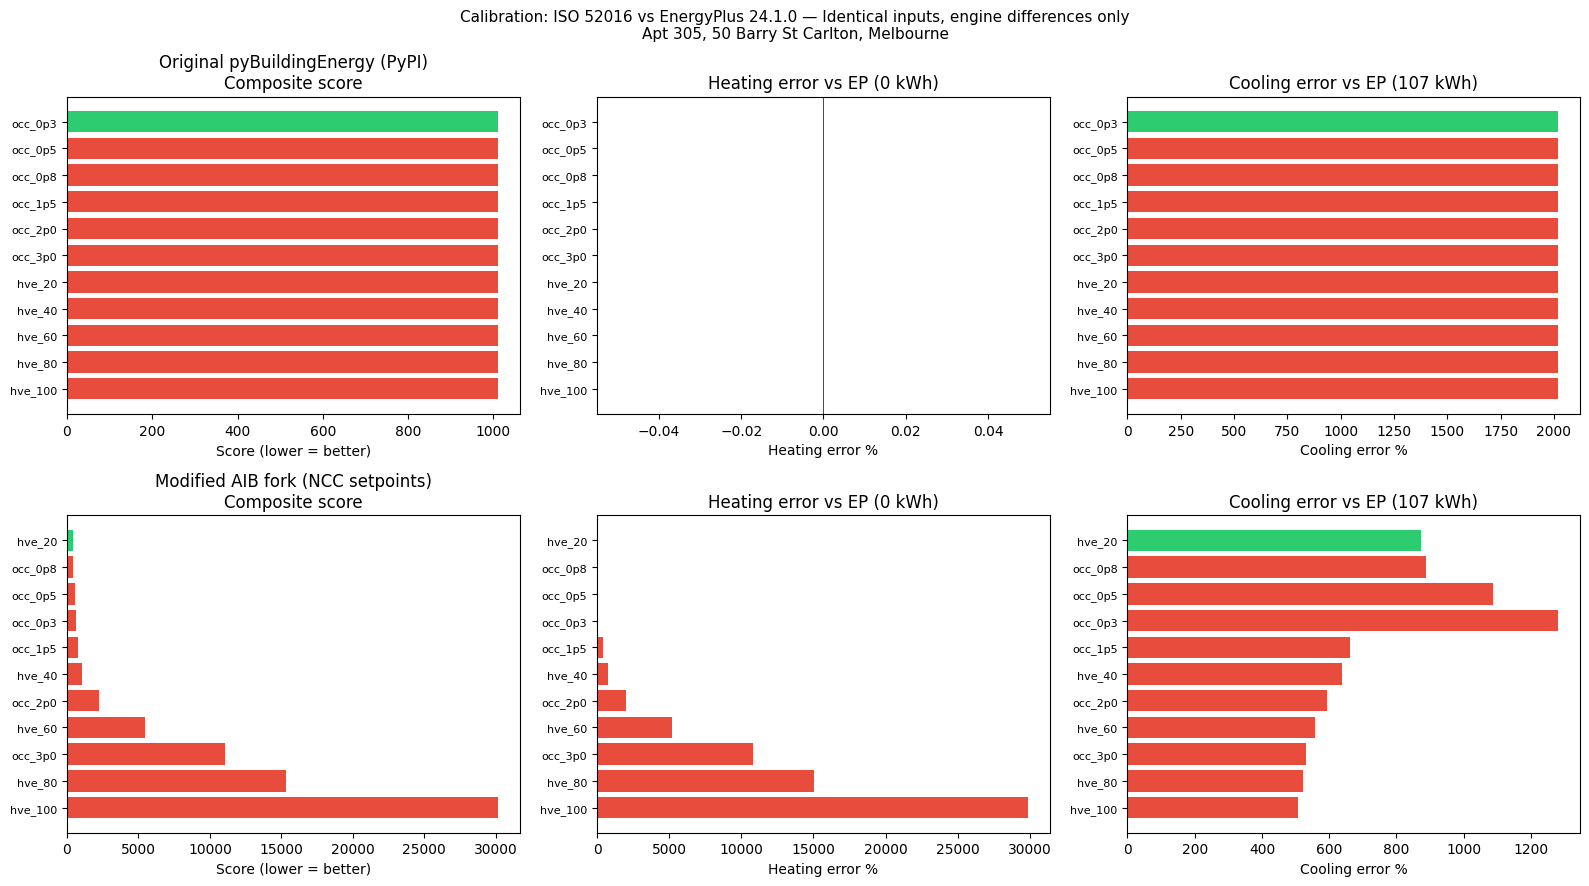


=== Best calibrated configurations ===
Engine                                    Best config        ΔH       ΔC    Score
------------------------------------------------------------------------------
Original pyBuildingEnergy (PyPI)          occ_0p3          0.0%  2021.7%   1010.9
Modified AIB fork (same 18/26 °C)         hve_20           0.0%   874.1%    437.1

Note: All three engines use identical inputs (18°C/26°C setpoints, 
      zero thermal mass, 5 W/m² appliances, 2 people). Differences
      in calibration score reflect engine methodology only.


In [ ]:
# ── Step 4: Comparison chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Calibration: ISO 52016 vs EnergyPlus 24.1.0 — Identical inputs, engine differences only\n"
             "Apt 305, 50 Barry St Carlton, Melbourne", fontsize=11)

for row_idx, (label, df, best) in enumerate([
        ("Original pyBuildingEnergy (PyPI)", orig_results, best_orig),
        ("Modified AIB fork (NCC setpoints)",  mod_results,  best_mod),
]):
    x      = np.arange(len(df))
    names  = df["candidate"].tolist()
    colors = ["#2ecc71" if i == 0 else ("#e74c3c" if df.iloc[i]["score"] > 50 else "#3498db")
              for i in range(len(df))]

    # Score
    ax = axes[row_idx][0]
    ax.barh(x, df["score"], color=colors)
    ax.set_yticks(x); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("Score (lower = better)"); ax.set_title(f"{label}\nComposite score")
    ax.invert_yaxis()

    # Heating error
    ax = axes[row_idx][1]
    ax.barh(x, df["heat_err_pct"], color=colors)
    ep_h_val = df["ep_heat_kWh"].iloc[0]
    ax.set_yticks(x); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("Heating error %"); ax.set_title(f"Heating error vs EP ({ep_h_val:.0f} kWh)")
    ax.axvline(0, color="k", lw=0.5); ax.invert_yaxis()

    # Cooling error
    ax = axes[row_idx][2]
    ax.barh(x, df["cool_err_pct"], color=colors)
    ep_c_val = df["ep_cool_kWh"].iloc[0]
    ax.set_yticks(x); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("Cooling error %"); ax.set_title(f"Cooling error vs EP ({ep_c_val:.0f} kWh)")
    ax.axvline(0, color="k", lw=0.5); ax.invert_yaxis()

plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n=== Best calibrated configurations ===")
print(f"{'Engine':40s}  {'Best config':12s}  {'ΔH':>7}  {'ΔC':>7}  {'Score':>7}")
print("-" * 78)
for label, best in [("Original pyBuildingEnergy (PyPI)", best_orig),
                    ("Modified AIB fork (same 18/26 °C)",  best_mod)]:
    print(f"{label:40s}  {best['candidate']:12s}  "
          f"{best['heat_err_pct']:6.1f}%  {best['cool_err_pct']:6.1f}%  {best['score']:7.1f}")
print("\nNote: All three engines use identical inputs (18°C/26°C setpoints, ")
print("      zero thermal mass, 5 W/m² appliances, 2 people). Differences")
print("      in calibration score reflect engine methodology only.")
